# 03 — Machine Learning Enzyme–Protein Screening

This notebook replaces the rule-based AMP scoring from notebook 02 with an ESM-2 language model classifier trained on curated AMP databases.

The goal is to identify protein–enzyme combinations that produce peptides with high ML-predicted antimicrobial probability, providing a more biologically grounded prioritization than the simple rule-based score.

The workflow:
1. Load or train the ESM-2 + logistic regression AMP classifier
2. Run screen_combinations_ml() across all whey proteins and enzymes
3. Rank combinations by ML-predicted AMP probability
4. Save top candidates for experimental validation

## Import HERALD ML Screening Workflow

This section imports the ML-based screening function and supporting modules.

The screen_combinations_ml() function combines:
* proteins.py — retrieves whey protein sequences from UniProt
* digestion.py — simulates enzymatic cleavage into peptide fragments
* predictor.py — computes ESM-2 embeddings and predicts AMP probability
* screening.py — summarizes ML scoring results across protein-enzyme combinations

The ESM-2 model and logistic regression classifier are loaded once here
and passed through the pipeline to avoid reloading on every peptide.

In [1]:
import sys
import os
import joblib
import esm
import torch
import pandas as pd

PROJECT_ROOT = os.path.abspath("..")
sys.path.append(PROJECT_ROOT)

from herald.proteins import WHEY_PROTEINS
from herald.enzymes import ENZYME_RULES
from herald.databases import build_amp_database
from herald.predictor import prepare_dataset, compute_esm2_embeddings, train_classifier
from herald.screening import screen_combinations_ml

                                            sequence    source
0  VMYAVYVVQNRWRMCTFLIRSDTLCDKMCTLCEFDKLNFDFYLCAT...  negative
1  PRWCNKAPICEDTEQCFIKHAGIWCLLTRWVNEDNTARQCTTYPTF...  negative
2  QNNATETNCSKYHVHGCFPMYWNWLLTCQKTTDDPTWDNCNHCPKD...  negative
3  AMEKFHPKEGCPAQRWTMCGSAVTNSMCSSDWIHPTGSDTWLFKTW...  negative
4                                            AFRNHIM  negative


## Load ESM-2 Model and AMP Classifier

This section loads the two components required for ML-based AMP scoring:

**ESM-2** is a protein language model developed by Meta and trained on 250 million 
protein sequences. It converts each peptide sequence into a 320-dimensional embedding 
vector that captures biological properties such as charge distribution, hydrophobicity, 
and structural context. ESM-2 is used here as a fixed feature extractor and importantly, its weights 
are not updated during training.

**The AMP classifier** is a logistic regression model trained on top of ESM-2 embeddings 
using 17,897 validated antimicrobial peptides from the APD6 and DBAASP databases as 
positive examples, and 18,000 randomly generated peptide sequences as negative examples. 
The classifier achieved 97% accuracy and a ROC-AUC of 0.996 on the held-out test set.

If a cached classifier is found in `data/processed/amp_classifier.pkl`, it is loaded 
directly to avoid retraining. Otherwise, the full training pipeline is run and the 
classifier is saved for future use.

Both the ESM-2 model and classifier are loaded once here and passed through the 
screening pipeline since loading them per peptide would be prohibitively slow.

In [2]:
model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()

PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
clf_path = os.path.join(PROCESSED_DIR, "amp_classifier.pkl")

if os.path.exists(clf_path):
    clf = joblib.load(clf_path)
    print("Loaded classifier from cache.")
else:
    amp_df = build_amp_database()
    X_train, X_test, y_train, y_test = prepare_dataset(amp_df, n_samples=18000)
    X_train_emb = compute_esm2_embeddings(X_train.tolist(), model, alphabet)
    clf = train_classifier(X_train_emb, y_train)
    print("Trained and saved new classifier.")

Loaded classifier from cache.


## Run ML-Based Protein–Enzyme Screening

This section runs the full ML screening pipeline across all whey proteins 
and enzymes defined in HERALD.

For each protein–enzyme combination, the workflow:
1. retrieves the protein sequence from the local UniProt cache,
2. simulates enzymatic digestion into candidate peptide fragments,
3. computes ESM-2 embeddings for each peptide,
4. predicts AMP probability using the trained logistic regression classifier, and
5. summarizes ML scoring metrics across all peptides for that combination.

Unlike the rule-based screening in notebook 02, which scored peptides using 
hand-crafted physicochemical heuristics, this notebook uses a classifier trained 
on 17,897 experimentally validated AMPs. The key output metric is amp_probability, the model's confidence that a given peptide is antimicrobial, rather than the 
simple_amp_score integer from the previous notebook.

The resulting table provides one row per protein–enzyme combination, ranked by 
the highest predicted AMP probability among all peptides produced by that combination.

In [3]:
results = screen_combinations_ml(
    proteins=WHEY_PROTEINS,
    enzymes=ENZYME_RULES,
    min_length=4,
    max_length=50,
    model=model,
    alphabet=alphabet,
    clf=clf,
)

results

,protein,accession_id,enzyme,min_length,max_length,num_peptides,num_predicted_amp,avg_probability,top_probability,top_peptide
0,beta-lactoglobulin,P02754,trypsin,4,50,13,9,0.568782,0.979667,IPAVFK
1,beta-lactoglobulin,P02754,chymotrypsin,4,50,19,14,0.563443,0.906080,ACQCL
2,beta-lactoglobulin,P02754,alcalase,4,50,16,6,0.373181,0.740172,QKKI
3,beta-lactoglobulin,P02754,papain,4,50,17,3,0.293294,0.691805,CQCL
4,beta-lactoglobulin,P02754,bromelain,4,50,18,6,0.440296,0.987578,CLLLA
5,beta-lactoglobulin,P02754,pepsin,4,50,18,9,0.504429,0.913464,LDIQKVAGT
6,alpha-lactalbumin,P00711,trypsin,4,50,10,3,0.386759,0.731806,MMSFVSLLLVGILFHATQAEQLTK
7,alpha-lactalbumin,P00711,chymotrypsin,4,50,16,6,0.450464,0.949486,VGIL
8,alpha-lactalbumin,P00711,alcalase,4,50,14,2,0.261182,0.721040,DDDL
9,alpha-lactalbumin,P00711,papain,4,50,14,3,0.238582,0.721040,DDDL


## Rank Screening Results by ML-Predicted AMP Probability

The screening results are sorted by the highest predicted AMP probability 
observed across all peptides produced by each protein–enzyme combination.

Unlike the rule-based ranking in notebook 02, which used integer score thresholds, 
this ranking is based on the ESM-2 classifier's confidence that the top peptide 
from each combination is genuinely antimicrobial. A top_probability close to 1.0 
indicates the model is highly confident that at least one peptide produced by that 
combination has strong antimicrobial potential.

In [4]:
ranked = results.sort_values("top_probability", ascending=False).reset_index(drop=True)
ranked

,protein,accession_id,enzyme,min_length,max_length,num_peptides,num_predicted_amp,avg_probability,top_probability,top_peptide
0,lactoferrin,P24627,trypsin,4,50,58,40,0.662260,0.999413,LFVPALLSLGALGLCLAAPR
1,lactoferrin,P24627,chymotrypsin,4,50,67,47,0.639616,0.999241,AVAVVKKANEGL
2,lactoferrin,P24627,pepsin,4,50,67,43,0.635619,0.995584,LAVAVVKKANEG
3,BSA,P02769,trypsin,4,50,62,36,0.558216,0.994314,GACLLPK
4,alpha-lactalbumin,P00711,bromelain,4,50,15,4,0.375430,0.993552,SLLLV
5,BSA,P02769,alcalase,4,50,57,23,0.405834,0.993433,KHKPKA
6,BSA,P02769,bromelain,4,50,52,20,0.443362,0.992316,TFISLLLLFSSA
7,lactoferrin,P24627,bromelain,4,50,58,27,0.462574,0.990635,LLSLG
8,lactoferrin,P24627,alcalase,4,50,62,26,0.441136,0.989600,GKCGL
9,beta-lactoglobulin,P02754,bromelain,4,50,18,6,0.440296,0.987578,CLLLA


## Top Candidate Peptides for Experimental Validation

This table summarizes the single highest-scoring peptide from each protein–enzyme 
combination. These candidates are the primary output of the computational pipeline 
and the starting point for Aim 2 wet lab validation.

Column descriptions:
- **top_peptide**: the peptide sequence recommended for synthesis and testing
- **top_probability**: ML confidence that this peptide is antimicrobial (0–1)
- **num_predicted_amp**: number of additional AMP-predicted peptides from this combination
- **avg_probability**: average AMP probability across all peptides from this combination

These predictions are based on sequence-derived ESM-2 embeddings and have not yet 
been experimentally validated. Candidates should be prioritized by top_probability 
but also considered in the context of synthesis feasibility, length, and the 
availability of the corresponding food-grade enzyme in the lab.

In [5]:
top_candidates = ranked[[
    "protein",
    "enzyme", 
    "top_peptide",
    "top_probability",
    "num_predicted_amp",
    "avg_probability",
]].copy()

top_candidates

,protein,enzyme,top_peptide,top_probability,num_predicted_amp,avg_probability
0,lactoferrin,trypsin,LFVPALLSLGALGLCLAAPR,0.999413,40,0.662260
1,lactoferrin,chymotrypsin,AVAVVKKANEGL,0.999241,47,0.639616
2,lactoferrin,pepsin,LAVAVVKKANEG,0.995584,43,0.635619
3,BSA,trypsin,GACLLPK,0.994314,36,0.558216
4,alpha-lactalbumin,bromelain,SLLLV,0.993552,4,0.375430
5,BSA,alcalase,KHKPKA,0.993433,23,0.405834
6,BSA,bromelain,TFISLLLLFSSA,0.992316,20,0.443362
7,lactoferrin,bromelain,LLSLG,0.990635,27,0.462574
8,lactoferrin,alcalase,GKCGL,0.989600,26,0.441136
9,beta-lactoglobulin,bromelain,CLLLA,0.987578,6,0.440296


## Save ML Screening Results

The ranked screening results are saved to data/processed/ as a CSV file for 
downstream analysis, sharing with collaborators, and iterative refinement after 
experimental validation.

These results represent the computational output of Aim 1 and will be updated 
in Aim 3 as wet lab MIC values are incorporated to recalibrate the model.

In [6]:
output_path = os.path.join(PROJECT_ROOT, "data", "processed", "ml_screening_results.csv")
ranked.to_csv(output_path, index=False)
print(f"Saved results to: {output_path}")

Saved results to: /Users/lukas/Developer/herald/data/processed/ml_screening_results.csv


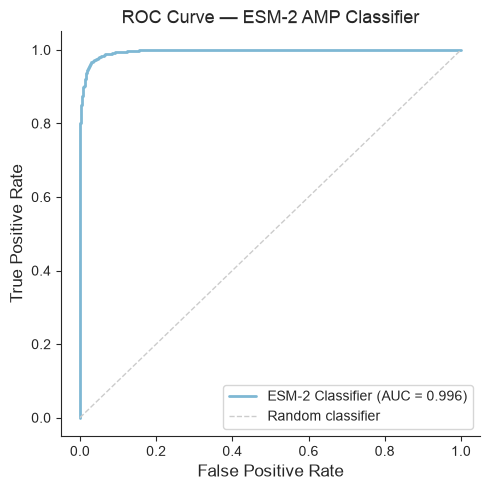

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import joblib
import os

# paths
DATA_DIR = os.path.join(PROJECT_ROOT, "data", "processed")

# load saved test data and classifier
X_test_emb = np.load(os.path.join(DATA_DIR, "X_test_emb.npy"))
y_test = np.load(os.path.join(DATA_DIR, "y_test.npy"))
clf = joblib.load(os.path.join(DATA_DIR, "amp_classifier.pkl"))

# compute ROC curve
y_prob = clf.predict_proba(X_test_emb)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# plot
fig, ax = plt.subplots(figsize=(5, 5))
sns.set_style("ticks")

ax.plot(fpr, tpr, color="#7eb8d4", linewidth=2,
        label=f"ESM-2 Classifier (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], color="#cccccc", linewidth=1,
        linestyle="--", label="Random classifier")

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve — ESM-2 AMP Classifier", fontsize=13)
ax.legend(loc="lower right", fontsize=10)

sns.despine(ax=ax)
plt.tight_layout()
os.makedirs(os.path.join(PROJECT_ROOT, "figures"), exist_ok=True)
plt.savefig(os.path.join(PROJECT_ROOT, "figures", "roc_curve.png"),
            dpi=300, bbox_inches="tight")
plt.show()

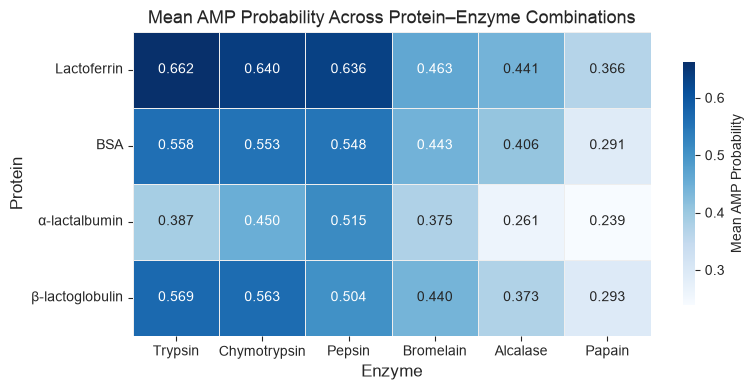

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# load ML screening results
pythonPROJECT_ROOT = os.path.abspath("..")
DATA_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
df = pd.read_csv(os.path.join(DATA_DIR, "ml_screening_results.csv"))

# clean protein names for display
protein_labels = {
    "beta-lactoglobulin": "β-lactoglobulin",
    "alpha-lactalbumin": "α-lactalbumin",
    "lactoferrin": "Lactoferrin",
    "BSA": "BSA"
}
df["protein"] = df["protein"].map(protein_labels)

# pivot to matrix: proteins as rows, enzymes as columns
enzyme_order = ["trypsin", "chymotrypsin", "pepsin",
                "bromelain", "alcalase", "papain"]
protein_order = ["Lactoferrin", "BSA", "α-lactalbumin", "β-lactoglobulin"]

pivot = df.pivot(index="protein", columns="enzyme", values="avg_probability")
pivot = pivot.loc[protein_order, enzyme_order]

# capitalize enzyme names for display
pivot.columns = [e.capitalize() for e in pivot.columns]

# plot
fig, ax = plt.subplots(figsize=(8, 4))
sns.set_style("ticks")

sns.heatmap(
    pivot,
    ax=ax,
    cmap="Blues",
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    linecolor="#eeeeee",
    cbar_kws={"label": "Mean AMP Probability", "shrink": 0.8},
    annot_kws={"size": 10}
)

ax.set_xlabel("Enzyme", fontsize=12)
ax.set_ylabel("Protein", fontsize=12)
ax.set_title("Mean AMP Probability Across Protein–Enzyme Combinations",
             fontsize=13)
ax.tick_params(axis="both", labelsize=10)
plt.tight_layout()
os.makedirs(os.path.join(PROJECT_ROOT, "figures"), exist_ok=True)
plt.savefig(os.path.join(PROJECT_ROOT, "figures", "amp_heatmap.png"),
            dpi=300, bbox_inches="tight")
plt.show()